<h2 style="color:GREEN;text-align:center;">Task 4:EDA on Retail Sales Data</h2>

<h3 style="color:violet">Step 1:Load Dataset&Initial Inspection</h3>

In [5]:
import pandas as pd
df=pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Shape:",df.shape)
print("\nData Types:")
print(df.dtypes)
print("\n Missing Values:")
print(df.isnull().sum())

Shape: (1000, 9)

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

 Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


<h3 style="color:violet">Step 2:Descriptive Statistics</h3>
This analysis calculates the mean, median, mode, and standard deviation of the numerical variables. These measures help understand the central tendency and variation in the retail sales data.

In [9]:
df.describe()



,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [11]:
print("Mean:")
print(df.mean(numeric_only=True))
print("\nMedian:")
print(df.median(numeric_only=True))
print("\nMode")
print(df.mode(numeric_only=True).iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


<h3 style="color:violet">Step 3:Time Series Analysis</h3>
This analysis examines monthly and quarterly sales trends using line charts. It helps identify changes in sales performance over time and periods of higher or lower sales.

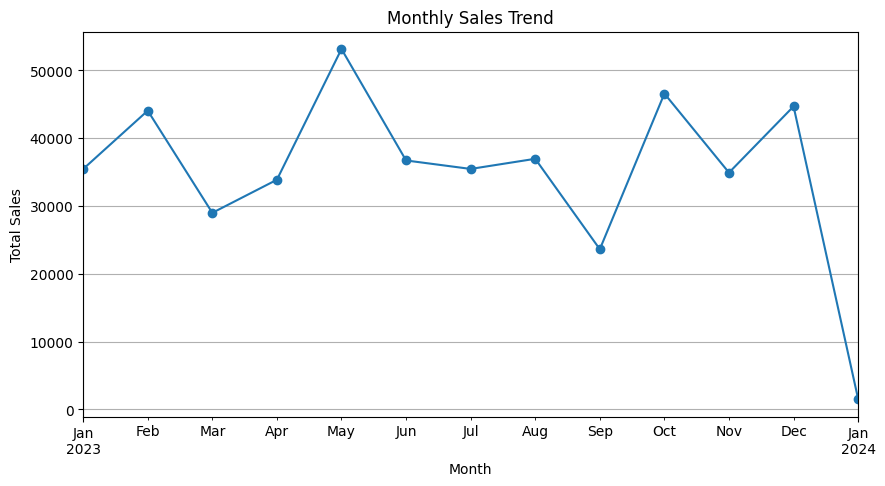

In [20]:
df['Date']=pd.to_datetime(df['Date'])
import matplotlib pyplot as plt
monthly_sales=df.groupby(df['Date'].dt.to_period('M'))["Total Amount"].sum()
monthly_sales.plot(kind='line',marker='o',figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

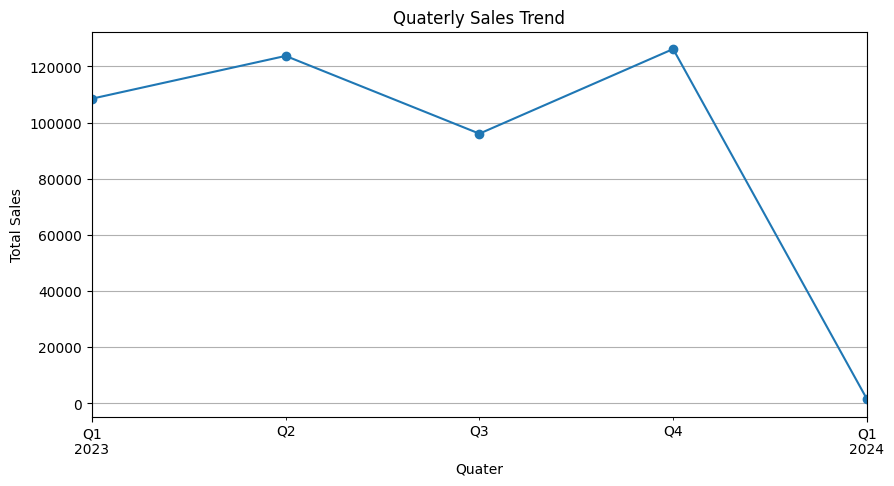

In [21]:
quaterly_sales=df.groupby(df['Date'].dt.to_period('Q'))["Total Amount"].sum()
quaterly_sales.plot(kind='line',marker='o',figsize=(10,5))
plt.title('Quaterly Sales Trend')
plt.xlabel('Quater')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()



<h3 style="color:violet">Step 4:Customer Demographics</h3>
This analysis examines customer age groups and gender distribution. It helps understand the demographic characteristics of the customers in the retail dataset.

In [25]:
df['Age Group']=pd.cut(df['Age'],bins=[0,18,25,35,45,55,100],labels=['<18','18-25','26-35','36-45','46-55','56+'])
df['Age Group'].value_counts().sort_index()


Age Group
<18       21
18-25    148
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64

In [26]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

<h3 style="color:violet">Step 5.1:Product Analysis</h3>
This analysis identifies the product categories with the highest total quantity sold. It helps understand which categories have greater customer demand.

In [60]:
top_products=df.groupby('Product Category')['Quantity'].sum().sort_values (ascending=False).head(10)
print(top_products)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


<h3 style="color:violet">Step 5.2:Revenue by Product Category</h3>
This analysis compares the total revenue generated by each product category. A bar chart is used to clearly compare the revenue contribution of different categories.

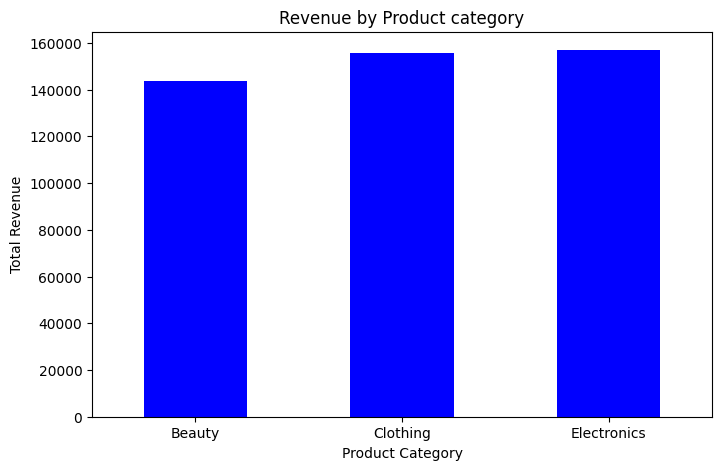

In [61]:
category_revenue=df.groupby('Product Category')['Total Amount'].sum()
category_revenue.plot(kind='bar',figsize=(8,5),color='blue')
plt.title('Revenue by Product category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

<h3 style="color:violet">Step 6: Correlation Analysis</h3>
The correlation heatmap shows the relationships between numerical variables. It helps identify which variables have stronger positive or negative relationships

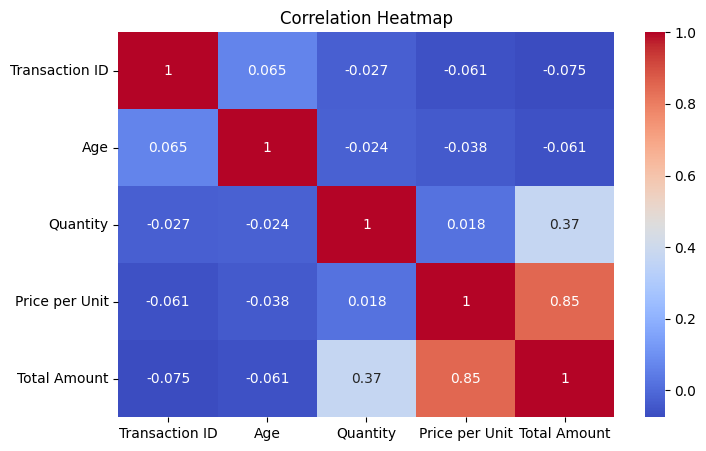

In [54]:
import seaborn as sns
plt.figure(figsize=(8,5))
corr=df.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<h3 style="color:violet">Step 7:Addition Visualization-Sales by Gender</h3>
 
This analysis compares the total sales generated by male and female customers. It helps understand whether there are differences in purchasing contribution between the two gender groups.

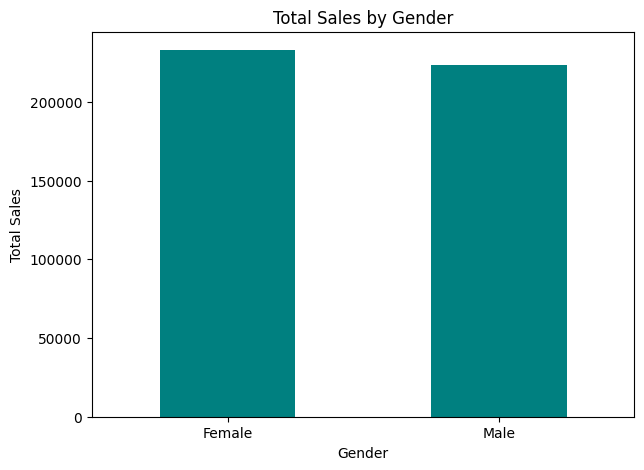

In [57]:
gender_sales=df.groupby('Gender')['Total Amount'].sum()
gender_sales.plot(kind='bar',figsize=(7,5),color='teal')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

<h3 style="color:violet">Step 8: Final Business Recommendations</h3> 

1. Focus on high-performing product categories by maintaining sufficient stock and improving their availability.

2. Use monthly and quarterly sales trends to plan inventory, promotions, and marketing campaigns during high-demand periods.

3. Analyse customer age groups and gender-based sales patterns to create more targeted marketing strategies.

4. Monitor product prices and quantities because they have a relationship with total sales revenue.

5. Use the identified sales patterns to improve inventory planning and reduce the risk of overstocking or stock shortages.


<h3 style="color:orange">Step 9:Conclusion</h3>


The EDA provided useful insights into retail sales trends, customer demographics, product categories, and numerical relationships. Monthly and quarterly analysis helped identify sales patterns, while customer and product analysis provided information about purchasing behaviour. These insights can support better inventory management, marketing strategies, and business decision-making.
